   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
Mean Values:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Standard Deviation:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64
           sepal length (cm)           sepal width (cm)            \
                        mean       std             mean       std   
species  

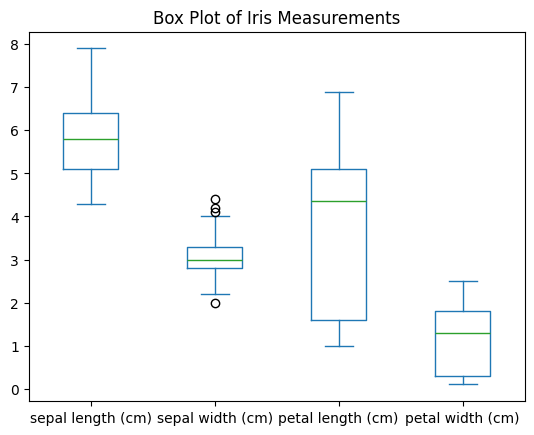

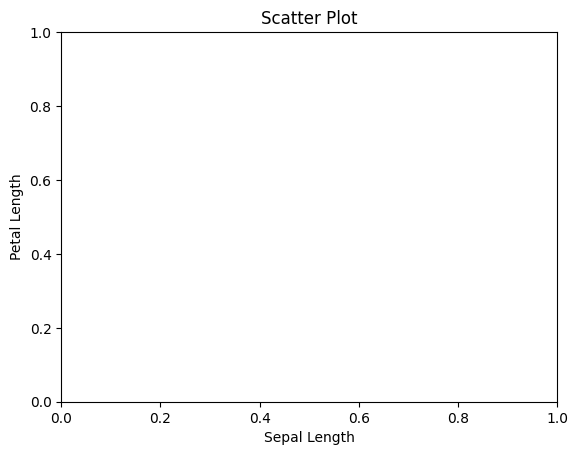

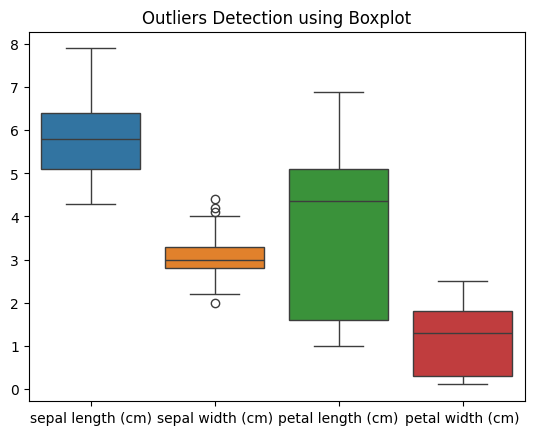

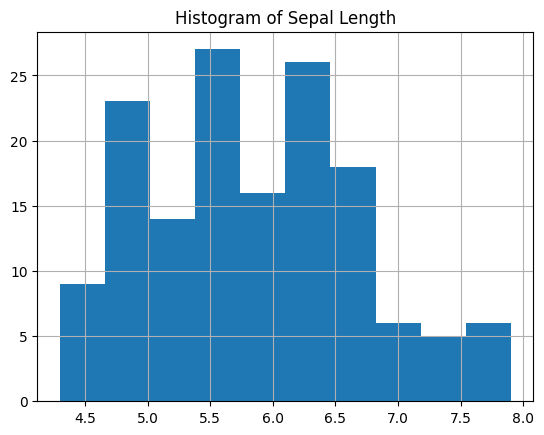

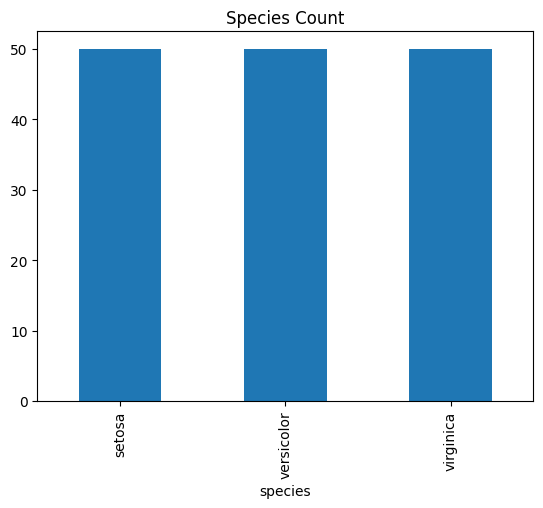

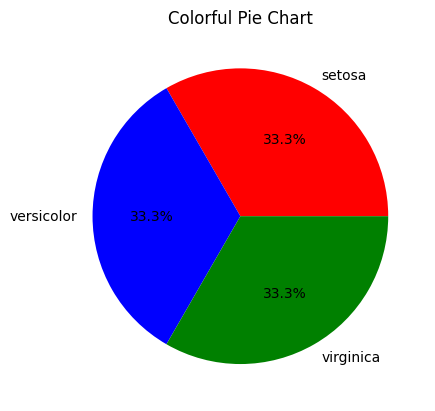

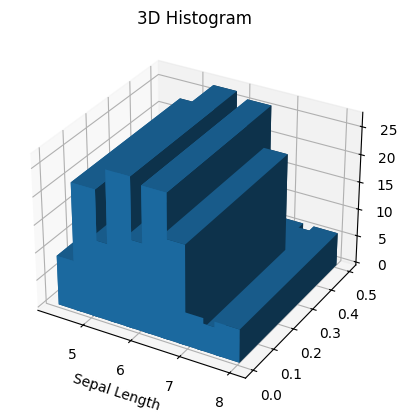

Coefficient: [1.85843298]
Intercept: -7.101443369602455


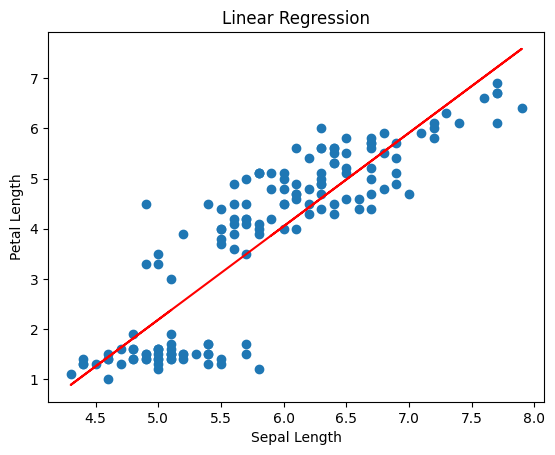

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


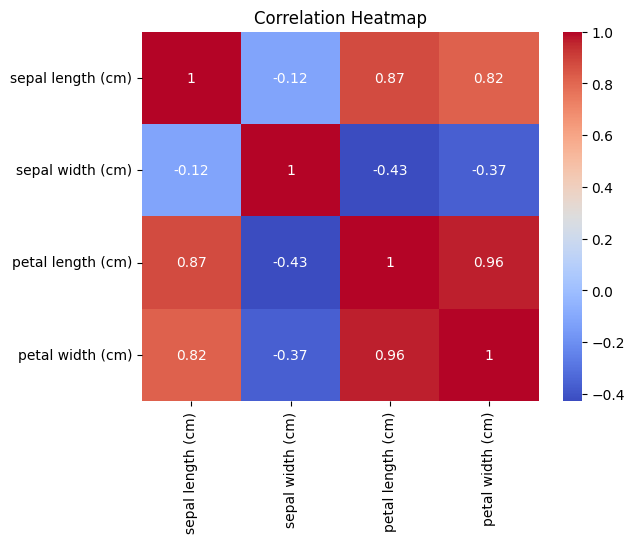

ANOVA Result: F_onewayResult(statistic=np.float64(119.26450218450468), pvalue=np.float64(1.6696691907693826e-31))


In [5]:
#1. Load Iris Dataset and Compute Mean & Standard Deviation
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add species column
df['species'] = iris.target
df['species'] = df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

print(df.head())

#Mean and Standard Deviation (Overall)
mean_values = df.iloc[:,0:4].mean()
std_values = df.iloc[:,0:4].std()

print("Mean Values:\n", mean_values)
print("\nStandard Deviation:\n", std_values)

#Mean and Standard Deviation for Each Species
group_stats = df.groupby('species').agg(['mean','std'])
print(group_stats)

#a) Data Distribution using Box Plot and Scatter Plot
import matplotlib.pyplot as plt

df.iloc[:,0:4].plot(kind='box')
plt.title("Box Plot of Iris Measurements")
plt.show()

#plt.scatter(df['sepal length (cm)'], df['petal length (cm)'])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Scatter Plot")
plt.show()

#b) Find Outliers Using Box Plot
import seaborn as sns

sns.boxplot(data=df.iloc[:,0:4])
plt.title("Outliers Detection using Boxplot")
plt.show()

#c) Histogram, Bar Chart and Pie Chart
df['sepal length (cm)'].hist()
plt.title("Histogram of Sepal Length")
plt.show()

species_counts = df['species'].value_counts()

species_counts.plot(kind='bar')
plt.title("Species Count")
plt.show()

#d) Colorful Pie Chart and 3D Histogram
colors = ['red','blue','green']

plt.pie(species_counts, labels=species_counts.index,
        autopct='%1.1f%%', colors=colors)

plt.title("Colorful Pie Chart")
plt.show()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges = np.histogram(df['sepal length (cm)'], bins=10)

xpos = xedges[:-1]
ypos = np.zeros_like(xpos)
zpos = np.zeros_like(xpos)

dx = 0.5
dy = 0.5
dz = hist

ax.bar3d(xpos, ypos, zpos, dx, dy, dz)

ax.set_xlabel('Sepal Length')
ax.set_zlabel('Frequency')

plt.title("3D Histogram")
plt.show()


#2. Regression Technique
from sklearn.linear_model import LinearRegression

X = df[['sepal length (cm)']]
y = df['petal length (cm)']

model = LinearRegression()
model.fit(X,y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

plt.scatter(X,y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Linear Regression")
plt.show()


#3. Correlation Matrix
corr_matrix = df.iloc[:,0:4].corr()

print(corr_matrix)

import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

from scipy.stats import f_oneway

setosa = df[df['species']=='setosa']['sepal length (cm)']
versicolor = df[df['species']=='versicolor']['sepal length (cm)']
virginica = df[df['species']=='virginica']['sepal length (cm)']

anova_result = f_oneway(setosa, versicolor, virginica)

print("ANOVA Result:", anova_result)